# A general state space model: a Kalman filter

The diagnostics are not specific to neural decoding. Any state space model gives, at
each time step, a **one-step predictive distribution** of the latent state
$p(x_t \mid y_{1:t-1})$ and the **likelihood** of the new observation
$p(y_t \mid x_t)$ as a function of the state. This tutorial checks a Kalman filter
that tracks a moving object from a noisy position sensor:

1. simulate the object and the sensor;
2. run the filter to get each step's prediction;
3. evaluate the prediction and the observation's likelihood **on a grid of states**,
   which is what the diagnostics take;
4. compute HPD overlap, KL divergence and the predictive p-value for every step;
5. find a period when the sensor was biased, and a filter whose noise settings are
   wrong.

It needs only NumPy, SciPy, matplotlib and `statespacecheck`.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import kstest, norm

import statespacecheck as ssc

rng = np.random.default_rng(3)

## 1. The model

The object's position $x_t$ follows a Gaussian random walk, and the sensor reports it
with Gaussian noise:

$$x_t = x_{t-1} + w_t,\ w_t \sim N(0, q^2), \qquad y_t = x_t + v_t,\ v_t \sim N(0, r^2).$$

For 60 steps in the middle of the recording the sensor reads 4 units too high, which
the filter does not know.

In [2]:
n_time = 600
q, r = 0.3, 1.0  # standard deviations of the process and the sensor noise
position = np.cumsum(rng.normal(0.0, q, n_time))
observed = position + rng.normal(0.0, r, n_time)
time = np.arange(n_time)
fault = (time >= 300) & (time < 360)
observed_with_fault = observed + 4.0 * fault

## 2. The Kalman filter

For this linear Gaussian model the one-step prediction is Gaussian, with a mean and
variance the filter updates at each step.

In [3]:
def kalman_predictions(
    observations: np.ndarray, q_model: float, r_model: float
) -> tuple[np.ndarray, np.ndarray]:
    """Return the mean and variance of each step's one-step prediction, (n_time,)."""
    mean, variance = 0.0, 10.0  # a broad initial state
    predicted_mean, predicted_variance = np.empty(n_time), np.empty(n_time)
    for t, y in enumerate(observations):
        # Predict: the random walk adds process noise
        predicted_mean[t], predicted_variance[t] = mean, variance + q_model**2
        # Update with the observation
        gain = predicted_variance[t] / (predicted_variance[t] + r_model**2)
        mean = predicted_mean[t] + gain * (y - predicted_mean[t])
        variance = (1.0 - gain) * predicted_variance[t]
    return predicted_mean, predicted_variance

## 3. Putting the distributions on a grid

The diagnostics compare two distributions over the state: the prediction and the
observation's likelihood. They take both as arrays of values on the **same grid of
states**, shape `(n_time, n_bins)` (or `(n_time, n_x, n_y)` for a 2-D state), with
equally sized bins. A model whose distributions are continuous, like this one, is
evaluated on such a grid:

- the grid covers every state where either distribution has appreciable mass;
- its spacing is small compared with the narrowest distribution (here 0.05, against
  standard deviations of 0.3 and more);
- the likelihood is $p(y_t \mid x)$ evaluated at each grid state $x$; it need not sum
  to one over the grid.

The functions normalize the prediction and the likelihood themselves. A decoder that
already works on a grid (such as a grid filter) passes its arrays directly.

In [4]:
grid = np.arange(position.min() - 15.0, position.max() + 15.0, 0.05)  # states
print(f"{grid.size} grid states from {grid[0]:.1f} to {grid[-1]:.1f}")


def on_grid(
    observations: np.ndarray, q_model: float, r_model: float
) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """Run the filter and put its prediction and the likelihood on the grid.

    Returns the prediction and each observation's likelihood, (n_time, n_bins), and
    the prediction's mean and variance, (n_time,).
    """
    mean, variance = kalman_predictions(observations, q_model, r_model)
    predictive = norm.pdf(grid, mean[:, np.newaxis], np.sqrt(variance)[:, np.newaxis])
    likelihood = norm.pdf(observations[:, np.newaxis], grid, r_model)  # p(y_t | x)
    return predictive, likelihood, mean, variance


predictive, likelihood, mean, variance = on_grid(observed, q, r)

888 grid states from -17.5 to 26.8


A check that the grid is fine and wide enough: the predictive density of each
observation, $p(y_t \mid y_{1:t-1}) = \sum_x p(x \mid y_{1:t-1})\, p(y_t \mid x)$,
computed on the grid by `log_predictive_density`, should match the exact value, a
normal density with the prediction's mean and variance plus the sensor's.

In [5]:
grid_log_density = ssc.log_predictive_density(predictive, observation_likelihood=likelihood)
exact_log_density = norm.logpdf(observed, mean, np.sqrt(variance + r**2))
print(f"largest difference: {np.abs(grid_log_density - exact_log_density).max():.1e}")

largest difference: 1.7e-08


## 4. Diagnostics for every step

- **HPD overlap** of the 95% highest-density regions of the prediction and the
  likelihood (low is poor fit);
- **KL divergence** from the prediction to the likelihood (high is poor fit; a
  reference, since it is also large when a broad prediction is consistent with a
  precise observation);
- the **predictive p-value**: the probability, under the prediction, of an
  observation with a predictive density no higher than the one observed (low is
  poor fit).

The p-value comes from `predictive_pvalue`, which compares the observed predictive
density with those of observations replicated from the model. For this model the
replicates are draws from the exact predictive distribution of $y_t$. (Here the
p-value is also known exactly, which checks the Monte Carlo estimate.)

In [6]:
def diagnose(observations: np.ndarray, q_model: float, r_model: float) -> dict:
    """HPD overlap, KL divergence and predictive p-value of every step, (n_time,)."""
    predictive, likelihood, mean, variance = on_grid(observations, q_model, r_model)
    spread = np.sqrt(variance + r_model**2)  # sd of the predicted observation
    log_density = ssc.log_predictive_density(predictive, observation_likelihood=likelihood)
    replicate_rng = np.random.default_rng(7)

    def replicated_log_density(n_samples: int) -> np.ndarray:
        replicates = mean + spread * replicate_rng.standard_normal((n_samples, n_time))
        return norm.logpdf(replicates, mean, spread)

    return {
        "hpd_overlap": ssc.hpd_overlap(predictive, likelihood),
        "kl_divergence": ssc.kl_divergence(predictive, likelihood),
        "pvalue": ssc.predictive_pvalue(log_density, replicated_log_density, n_samples=2000),
        "exact_pvalue": 2.0 * norm.sf(np.abs(observations - mean) / spread),
    }


correct = diagnose(observed, q, r)
difference = np.abs(correct["pvalue"] - correct["exact_pvalue"]).max()
print(f"largest Monte Carlo p-value error: {difference:.3f} (2,000 replicates)")
print(f"steps with p <= 0.05: {np.mean(correct['pvalue'] <= 0.05):.1%}")
print(
    f"KS test of uniform exact p-values: p = {kstest(correct['exact_pvalue'], 'uniform').pvalue:.2f}"
)

largest Monte Carlo p-value error: 0.031 (2,000 replicates)
steps with p <= 0.05: 5.3%
KS test of uniform exact p-values: p = 0.65


With the true noise settings and no fault, about 5% of steps have $p \le 0.05$, and
the exact p-values are close to uniform, as they should be when the model generated
the data. The Monte Carlo error is within a few standard errors of 2,000 replicates.

## 5. A biased sensor

The same filter, run on the recording in which the sensor read 4 units too high
for 60 steps:

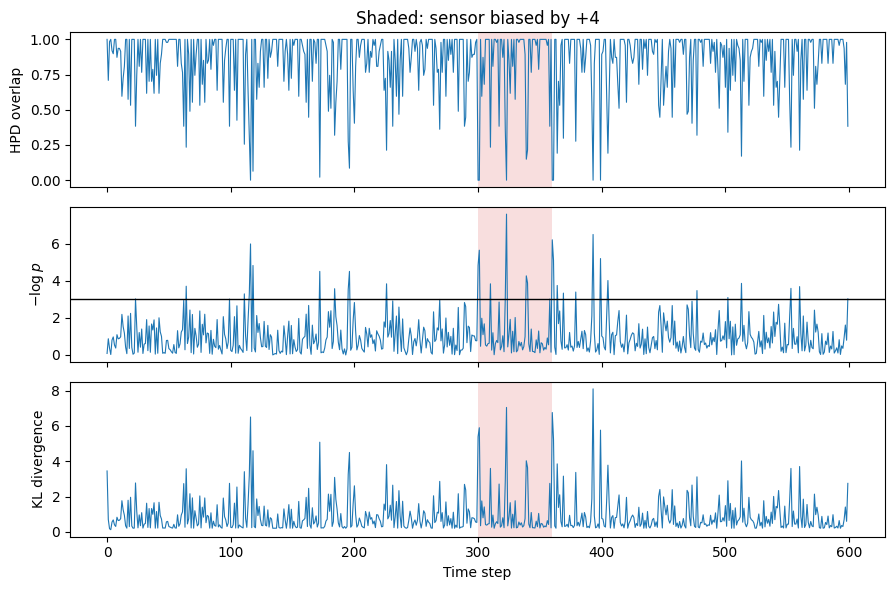

p <= 0.05 in the first 5 steps of the fault: 40%
p <= 0.05 in the rest of the fault: 11%
p <= 0.05 in the 5 steps after it ends: 60%
p <= 0.05 elsewhere: 4.5%


In [7]:
faulty = diagnose(observed_with_fault, q, r)
panels = [
    ("HPD overlap", faulty["hpd_overlap"]),
    ("$-\\log p$", -np.log(np.maximum(faulty["pvalue"], 1 / 2000))),
    ("KL divergence", faulty["kl_divergence"]),
]
fig, axes = plt.subplots(3, 1, sharex=True, figsize=(9, 6))
for ax, (label, values) in zip(axes, panels, strict=True):
    ax.axvspan(300, 360, color="tab:red", alpha=0.15, lw=0)
    ax.plot(time, values, lw=0.8)
    ax.set_ylabel(label)
axes[1].axhline(-np.log(0.05), color="k", lw=1)
axes[-1].set_xlabel("Time step")
axes[0].set_title("Shaded: sensor biased by +4")
fig.tight_layout()
plt.show()

flagged = faulty["pvalue"] <= 0.05
onset = (time >= 300) & (time < 305)
recovery = (time >= 360) & (time < 365)
print(f"p <= 0.05 in the first 5 steps of the fault: {flagged[onset].mean():.0%}")
print(f"p <= 0.05 in the rest of the fault: {flagged[fault & ~onset].mean():.0%}")
print(f"p <= 0.05 in the 5 steps after it ends: {flagged[recovery].mean():.0%}")
print(f"p <= 0.05 elsewhere: {flagged[~fault & ~recovery].mean():.1%}")

The p-values drop sharply where the bias starts and ends, then recover: after a few
steps the filter has followed the biased readings, and its prediction is consistent
with them again. The diagnostics measure whether each observation is consistent with
the prediction, not whether the estimate is right, so a sustained offset that the
model absorbs shows only at its edges.

## 6. Wrong noise settings

Two filters with the wrong noise settings, run on the recording without the fault:

- **overconfident sensor**: the filter assumes a sensor noise of 0.3 instead of 1.0,
  so each observation's likelihood is too narrow;
- **sluggish dynamics**: the filter assumes a process noise of 0.05 instead of 0.3,
  so its prediction lags behind the object.

In [8]:
settings = {
    "correct": (q, r),
    "overconfident sensor": (q, 0.3),
    "sluggish dynamics": (0.05, r),
}
print(f"{'filter':22s} p <= 0.05   mean HPD overlap   median KL   infinite KL")
for name, (q_model, r_model) in settings.items():
    result = diagnose(observed, q_model, r_model)
    print(
        f"{name:22s} {np.mean(result['pvalue'] <= 0.05):9.1%} "
        f"{result['hpd_overlap'].mean():18.2f} {np.median(result['kl_divergence']):11.2f} "
        f"{np.mean(np.isinf(result['kl_divergence'])):13.0%}"
    )

filter                 p <= 0.05   mean HPD overlap   median KL   infinite KL
correct                     5.3%               0.86        0.54            0%
overconfident sensor       45.0%               0.44         inf          100%


sluggish dynamics          17.7%               0.82        1.44            0%


Both misspecifications raise the fraction of small p-values well above 5% and lower
the typical HPD overlap. The overconfident sensor's KL divergence is infinite at
every step: its narrow likelihood, evaluated on the grid, is exactly zero at states
where the broader prediction still has a tiny probability. KL divergence is
sensitive to such tails, which is one reason to treat it as a reference and to rely
on HPD overlap and the p-value.

## Summary

- The diagnostics take the prediction and the observation's likelihood on a shared
  grid of states, `(n_time, n_bins)`. Evaluate continuous distributions on a grid
  that covers both and resolves the narrower one, and check it, for example by
  comparing the grid's predictive density with an exact one.
- HPD overlap and the predictive p-value flag when the prediction and the
  observation disagree: at the edges of a sensor fault, and throughout a filter
  with the wrong noise settings.
- A problem the model absorbs consistently, like a sustained sensor offset, is
  visible only where it starts and ends. See
  [Interpreting the diagnostics](../../interpretation/) for what the diagnostics do
  and do not check.